# Alcohol y rendimiento académico: qué muestran los datos y qué no permiten concluir
**Luis Javier Rubio Hernández** · Matemático · Magíster en Matemáticas · Estudiante de Maestría en Ciencia de Datos

Análisis exploratorio revisado de 406 respuestas. Fuente declarada: Joshua Naudé, *Effects of Alcohol on Student Performance*, Kaggle (estudiantes de Stellenbosch University, según la ficha del conjunto).

**Pregunta principal:** ¿cómo se relacionan las categorías de bebidas por salida con el promedio universitario declarado de 2023? Se describen diferencias, una asociación monótona y asociaciones ajustadas. No se estima un efecto causal ni se valida un modelo predictivo fuera de muestra.

Este análisis se revisó después de conocer resultados de una versión anterior: no es un protocolo prerregistrado ni una confirmación independiente. Se muestran todos los contrastes definidos aquí, con su alcance exploratorio. No encontrar evidencia suficiente no equivale a demostrar que no existe asociación.

## Cómo ejecutar
Coloca `alcohol_rendimiento_estudiantil.csv` junto a este notebook, o en `data/raw/` desde la raíz del repositorio. Ejecuta todas las celdas en orden desde un kernel limpio. En Colab, carga también el CSV. No se descarga una URL desconocida ni se ocultan errores.

Dependencias: Python, numpy, pandas, scipy, matplotlib y statsmodels. Si faltan, instala con `%pip install numpy pandas scipy matplotlib statsmodels` en una celda separada. Las versiones efectivamente usadas se imprimen abajo. Se guardan figuras, tablas y un resumen numérico en `resultados_alcohol/`.

In [1]:
from pathlib import Path
import hashlib, json, sys, importlib.metadata
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.diagnostic import het_breuschpagan, lilliefors
from IPython.display import display

SEED = 20260908
B_BOOT = 20000
B_PERM = 19999
OUT = Path('resultados_alcohol')
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
AZUL, GRIS = '#0076A8', '#74828B'
versiones = {'Python': sys.version.split()[0]}
versiones.update({p: importlib.metadata.version(p) for p in
                 ['numpy', 'pandas', 'scipy', 'matplotlib', 'statsmodels']})
print(versiones)

{'Python': '3.12.13', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scipy': '1.17.0', 'matplotlib': '3.10.8', 'statsmodels': '0.15.0'}


## 1. Fuente, alcance y variables
El archivo es una encuesta de 17 columnas. Se analiza la copia proporcionada y se registra su SHA-256 para identificarla. No se dispone de un marco muestral, probabilidades de selección o tasa de respuesta; no se trata como muestra representativa de una universidad o de todos los universitarios. La referencia a Stellenbosch procede de la ficha pública, no de una verificación institucional del cuestionario.

El consumo pregunta por **bebidas en una salida**, no por consumo semanal, gramos de alcohol ni bebidas estándar. Las categorías `1-3`, `3-5`, `5-8` tienen límites que se solapan y `8+` es abierta: se conservan como respuestas ordinales, sin inventar cantidades exactas. La opción `Only weekends` describe cuándo se sale y no permite asignar 1,5 salidas por semana.

La pregunta original `Your Sex?` se denomina `sexo`; no mide identidad de género. Los promedios se tratan como puntuaciones numéricas sobre 100: 80 puntos no significan el doble de aprendizaje que 40. Una marca temporal repetida no prueba duplicación de personas y una única no prueba independencia. No hay identificadores que permitan verificar participantes repetidos.

In [2]:
candidatos = [Path('alcohol_rendimiento_estudiantil.csv'),
              Path('data/raw/alcohol_rendimiento_estudiantil.csv'),
              Path('../data/raw/alcohol_rendimiento_estudiantil.csv'),
              Path('../data/alcohol_rendimiento_estudiantil.csv')]
ruta = next((p for p in candidatos if p.is_file()), None)
if ruta is None:
    raise FileNotFoundError('Carga el CSV junto al notebook o en data/raw/.')
sha256 = hashlib.sha256(ruta.read_bytes()).hexdigest()
raw = pd.read_csv(ruta)
assert raw.shape[1] == 17, 'El esquema cambió; revisa el diccionario antes de continuar.'
nombres = ['fecha', 'sexo', 'previo', 'ano', 'facultad', 'promedio',
           'alojamiento', 'presupuesto', 'beca', 'estudio', 'fiestas', 'consumo',
           'clases', 'reprobaciones', 'pareja', 'aprobacion', 'relacion_padres']
diccionario = pd.DataFrame({'original': raw.columns, 'variable': nombres})
df = raw.copy()
df.columns = nombres
for c in df.select_dtypes('object'):
    df[c] = df[c].str.strip()
for c in ['previo', 'promedio']:
    df[c] = pd.to_numeric(df[c], errors='raise')
    assert df[c].dropna().between(0, 100).all(), f'Fuera de dominio: {c}'
df['fecha'] = pd.to_datetime(df['fecha'].str.replace(' EET', '', regex=False),
                           format='%Y/%m/%d %I:%M:%S %p', errors='raise')
df['beca'] = df['beca'].replace({'Yes (NSFAS, etc...)':'Yes'})
df['alojamiento'] = df['alojamiento'].replace({
    'Private accommodation/ stay with family/friends':'Privado/familia',
    'Non-private accommodation ie. Res':'Residencia'})
niveles = ['0', '1-3', '3-5', '5-8', '8+']
for c in ['consumo', 'estudio']:
    assert set(df[c].dropna()) <= set(niveles)
    df[c+'_rango'] = df[c].map(dict(zip(niveles, range(5))))
for c in ['clases','reprobaciones']:
    assert set(df[c].dropna()) <= {'0','1','2','3','4+'}
    df[c+'_rango'] = df[c].map({'0':0,'1':1,'2':2,'3':3,'4+':4})
print('Dimensiones originales:', raw.shape, '| SHA-256:', sha256)
print('Filas enteramente duplicadas:', int(raw.duplicated().sum()))
print('Marcas temporales distintas:', df.fecha.nunique())
display(diccionario)
diccionario.to_csv(OUT/'diccionario.csv', index=False)

Dimensiones originales: (406, 17) | SHA-256: 46bd1ebaf4a5e54e70240c005777b3524593bc6aaa868660eea6f5bfe11f800f
Filas enteramente duplicadas: 0
Marcas temporales distintas: 400


,original,variable
0,Timestamp,fecha
1,Your Sex?,sexo
2,Your Matric (grade 12) Average/ GPA (in %),previo
3,What year were you in last year (2023) ?,ano
4,What faculty does your degree fall under?,facultad
5,Your 2023 academic year average/GPA in % (Igno...,promedio
6,Your Accommodation Status Last Year (2023),alojamiento
7,Monthly Allowance in 2023,presupuesto
8,Were you on scholarship/bursary in 2023?,beca
9,Additional amount of studying (in hrs) per week,estudio


## 2. Calidad, faltantes y población analítica
Se conservan las puntuaciones extremas dentro de 0-100. La regla de Tukey solo las señala; no demuestra error ni explica su causa. Se muestran los faltantes por variable y su cruce con el año cursado.

El formulario pide omitir el promedio a quienes ingresaron en 2024. La coincidencia entre año y promedio faltantes es **compatible con** ese mecanismo, pero no identifica con certeza a todos los estudiantes de primer ingreso. Se distinguen los promedios ausentes con y sin año informado. No se imputa una nota potencialmente no aplicable; tampoco se afirma que todos los demás faltantes sean ignorables. Los análisis se refieren a participantes con datos disponibles. La selección por disponibilidad puede sesgar resultados.

{'n_total': 406, 'n_promedio': 320, 'faltan_promedio': 86, 'sin_ano_y_sin_promedio': 72, 'con_ano_sin_promedio': 14, 'marcas_distintas': 400, 'duplicados': 0}


,faltantes,porcentaje
promedio,86,21.18
ano,73,17.98
presupuesto,31,7.64
alojamiento,23,5.67
beca,8,1.97
facultad,7,1.72
previo,7,1.72
aprobacion,4,0.99
pareja,3,0.74
relacion_padres,3,0.74


promedio,False,True
ano,,
1st Year,118,10
2nd Year,149,4
3rd Year,40,0
4th Year,7,0
Postgraduate,5,0
Sin dato,1,72


,count,mean,std,min,25%,50%,75%,max,atipicos_Tukey
previo,399.0,77.99,7.05,34.0,74.0,78.0,83.0,99.00,8.0
promedio,320.0,66.27,9.15,30.0,60.0,65.0,73.0,95.22,2.0


,Sin promedio,Con promedio
consumo,,
0,6,20
1-3,21,69
3-5,20,71
5-8,20,91
8+,17,69


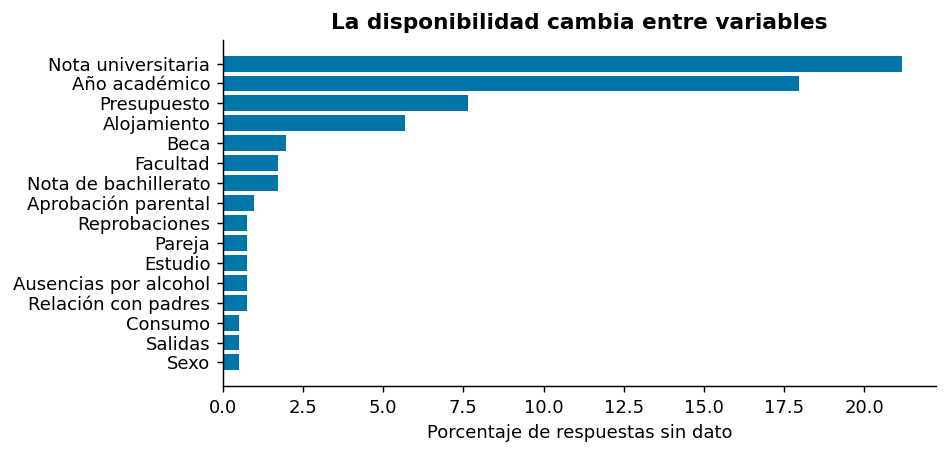

In [3]:
faltantes = pd.DataFrame({'faltantes':df[nombres].isna().sum(),
                          'porcentaje':100*df[nombres].isna().mean()})
display(faltantes.sort_values('faltantes', ascending=False).round(2))
cruce = pd.crosstab(df.ano.fillna('Sin dato'), df.promedio.isna())
display(cruce)
resumen_calidad = {'n_total':len(df), 'n_promedio':int(df.promedio.notna().sum()),
 'faltan_promedio':int(df.promedio.isna().sum()),
 'sin_ano_y_sin_promedio':int((df.ano.isna() & df.promedio.isna()).sum()),
 'con_ano_sin_promedio':int((df.ano.notna() & df.promedio.isna()).sum()),
 'marcas_distintas':int(df.fecha.nunique()), 'duplicados':int(raw.duplicated().sum())}
print(resumen_calidad)
resumen_num = df[['previo','promedio']].describe().T
for c in ['previo','promedio']:
    s=df[c].dropna(); q1,q3=s.quantile([.25,.75]); iqr=q3-q1
    resumen_num.loc[c,'atipicos_Tukey']=int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum())
display(resumen_num.round(2))
# Distribución del consumo según disponibilidad de la nota; descripción, no prueba de MAR.
seleccion = pd.crosstab(df.consumo, df.promedio.notna()).reindex(niveles)
seleccion.columns=['Sin promedio','Con promedio']
display(seleccion)
faltantes.to_csv(OUT/'faltantes.csv'); seleccion.to_csv(OUT/'seleccion.csv')
fig,ax=plt.subplots(figsize=(7.4,3.6))
f=faltantes[faltantes.faltantes>0].sort_values('porcentaje')
etiquetas_faltantes = {'promedio':'Nota universitaria', 'ano':'Año académico', 'presupuesto':'Presupuesto', 'alojamiento':'Alojamiento', 'beca':'Beca', 'facultad':'Facultad', 'previo':'Nota de bachillerato', 'aprobacion':'Aprobación parental', 'reprobaciones':'Reprobaciones', 'pareja':'Pareja', 'estudio':'Estudio', 'clases':'Ausencias por alcohol', 'relacion_padres':'Relación con padres', 'consumo':'Consumo', 'fiestas':'Salidas', 'sexo':'Sexo'}
ax.barh([etiquetas_faltantes.get(v,v) for v in f.index], f.porcentaje, color=AZUL)
ax.set(xlabel='Porcentaje de respuestas sin dato', title='La disponibilidad cambia entre variables')
fig.tight_layout(); fig.savefig(OUT/'faltantes.png',dpi=180); plt.show()

### Distribuciones y normalidad
Shapiro-Wilk y Lilliefors se muestran como diagnósticos descriptivos; no seleccionan automáticamente todas las pruebas posteriores. Lilliefors contempla que media y varianza se estiman con los mismos datos. Se elimina el KS estándar de la versión anterior. Spearman se elige por la escala ordinal del consumo y la pregunta sobre tendencia monótona; Kruskal-Wallis contrasta distribuciones entre grupos. Su lectura como prueba exclusivamente de medianas requiere condiciones adicionales sobre la forma de las distribuciones.

,variable,n,Shapiro_W,Shapiro_p,Lilliefors_D,Lilliefors_p
0,previo,399,0.966077,5.474000e-08,0.055024,0.00568
1,promedio,320,0.977446,6.386472e-05,0.114516,0.00100


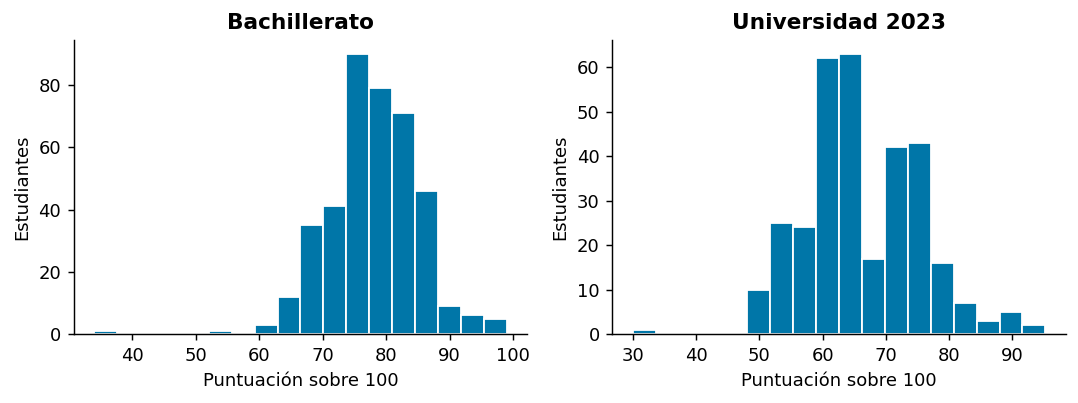

In [4]:
normalidad=[]
for c in ['previo','promedio']:
    s=df[c].dropna(); sw=stats.shapiro(s); ks= lilliefors(s, dist='norm', pvalmethod='table')
    normalidad.append({'variable':c,'n':len(s),'Shapiro_W':sw.statistic,
                       'Shapiro_p':sw.pvalue,'Lilliefors_D':ks[0],'Lilliefors_p':ks[1]})
display(pd.DataFrame(normalidad))
fig,axs=plt.subplots(1,2,figsize=(8.4,3.2))
for ax,c in zip(axs,['previo','promedio']):
    ax.hist(df[c].dropna(), bins=18,color=AZUL,edgecolor='white')
    ax.set(title='Bachillerato' if c=='previo' else 'Universidad 2023', xlabel='Puntuación sobre 100',ylabel='Estudiantes')
fig.tight_layout(); fig.savefig(OUT/'distribuciones.png',dpi=180); plt.show()

## 3. Asociación principal y su incertidumbre
Se usa Spearman con rangos y empates. El valor p principal se aproxima mediante **19.999 permutaciones**, barajando una variable bajo la hipótesis de independencia y asumiendo observaciones intercambiables. Es un contraste bilateral por magnitud absoluta; se incluye la corrección `(extremos + 1)/(B + 1)`. Esta hipótesis de independencia es más fuerte que afirmar solo correlación cero.

El IC del 95 % se estima por **20.000 remuestreos bootstrap de pares**, recalculando rangos en cada muestra y tomando percentiles 2,5 y 97,5. Es un intervalo aproximado, no una garantía exacta. Presupone que las filas pueden tratarse como observaciones independientes; no corrige selección, autorreporte ni dependencia no registrada. Semillas fijas hacen reproducible el cálculo.

{'n': 320, 'rho': -0.07080288126600737, 'p_permutacion': 0.2054, 'p_asintotico': 0.20652095305411194, 'ic_inf': -0.18287500225324219, 'ic_sup': 0.042646711441200136, 'error_MC_p_aprox': 0.002856737658151755}


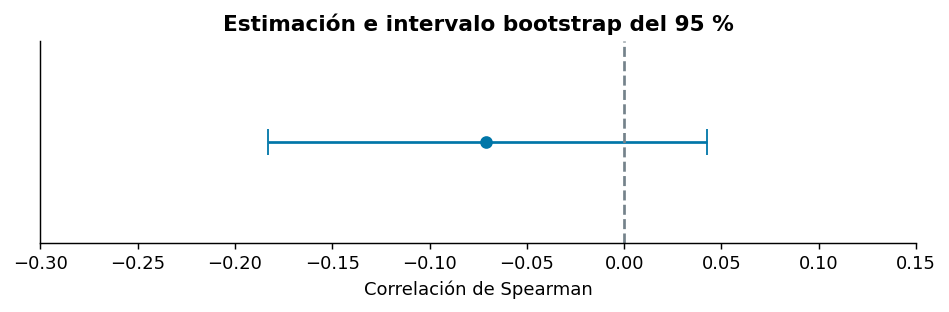

In [5]:
def spearman_perm(x, y, B=B_PERM, seed=SEED):
    x,y=np.asarray(x),np.asarray(y)
    a=stats.rankdata(x); b=stats.rankdata(y)
    a=a-a.mean(); b=b-b.mean()
    den=np.sqrt(np.dot(a,a)*np.dot(b,b))
    obs=np.dot(a,b)/den
    rng=np.random.default_rng(seed); extremos=0
    for _ in range(B):
        extremos += abs(np.dot(a,rng.permutation(b))/den) >= abs(obs)-1e-14
    return float(obs), (int(extremos)+1)/(B+1)

def spearman_boot(x,y,B=B_BOOT,seed=SEED+1):
    x,y=np.asarray(x),np.asarray(y); rng=np.random.default_rng(seed); vals=[]
    for ini in range(0,B,250):
        idx=rng.integers(0,len(x),size=(min(250,B-ini),len(x)))
        a=stats.rankdata(x[idx],axis=1); b=stats.rankdata(y[idx],axis=1)
        a-=a.mean(axis=1,keepdims=True); b-=b.mean(axis=1,keepdims=True)
        den=np.sqrt((a*a).sum(1)*(b*b).sum(1))
        vals.extend(((a*b).sum(1)/den).tolist())
    vals=np.asarray(vals)
    if not np.isfinite(vals).all():
        raise ValueError('Remuestras degeneradas: revisar antes de interpretar el IC.')
    return np.quantile(vals,[.025,.975]), vals

principal=df[['consumo_rango','promedio']].dropna()
rho,p_perm=spearman_perm(principal.consumo_rango,principal.promedio)
ic_rho, boots=spearman_boot(principal.consumo_rango,principal.promedio)
resultado_principal={'n':len(principal),'rho':rho,'p_permutacion':p_perm,
 'p_asintotico':float(stats.spearmanr(principal.consumo_rango,principal.promedio).pvalue),
 'ic_inf':float(ic_rho[0]),'ic_sup':float(ic_rho[1]),
 'error_MC_p_aprox':float(np.sqrt(p_perm*(1-p_perm)/B_PERM))}
print(resultado_principal)
fig,ax=plt.subplots(figsize=(7.4,2.5))
ax.errorbar(rho,0,xerr=[[rho-ic_rho[0]],[ic_rho[1]-rho]],fmt='o',capsize=7,color=AZUL)
ax.axvline(0,color=GRIS,ls='--'); ax.set_yticks([])
ax.set(xlim=(-.30,.15),xlabel='Correlación de Spearman',title='Estimación e intervalo bootstrap del 95 %')
fig.tight_layout();fig.savefig(OUT/'correlacion_ic.png',dpi=180);plt.show()

### Diferencias entre categorías
Se muestran medias e IC de Student individuales (aproximados), medianas y tamaños de grupo. La incertidumbre de la media del grupo sin consumo es mayor porque contiene pocos participantes. El solapamiento de IC individuales no constituye una prueba formal de diferencias.

Kruskal-Wallis examina diferencias generales entre las cinco distribuciones, no solo una tendencia creciente o decreciente. Se calcula su referencia asintótica y una referencia por permutación. No es una replicación independiente de Spearman. Para evitar ambigüedades de nomenclatura se informa la medida ajustada basada en H como `max(0, (H-k+1)/(n-k))`, sin interpretarla como proporción de variación de las notas explicada causalmente.

{'H': 5.771944605010676, 'gl': 4, 'n': 320, 'p_asintotico': 0.2168392292450809, 'p_permutacion': 0.2214, 'H_ajustado': 0.00562522096828786}
Diferencia de medias e IC de Welch (ilustrativo): {'media_8mas_menos_0': -1.1497028985507285, 'ic_inf': -6.777532530613678, 'ic_sup': 4.478126733512221}


,count,mean,median,std,ic_inf,ic_sup
consumo,,,,,,
0,20,66.855,65.0,11.072,61.674,72.037
1-3,69,66.820,65.0,9.236,64.601,69.039
3-5,71,67.937,69.0,9.022,65.801,70.072
5-8,91,64.846,63.0,7.976,63.185,66.507
8+,69,65.706,65.0,9.933,63.320,68.092


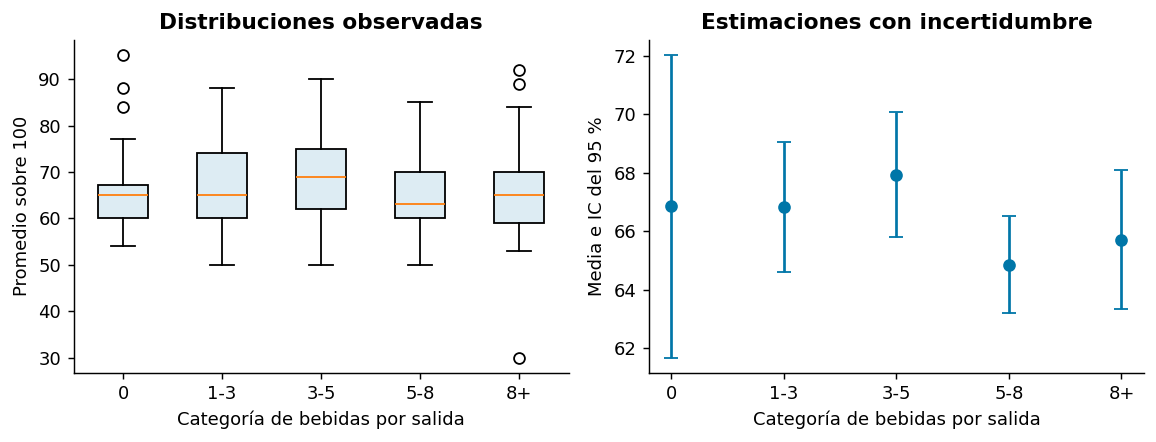

In [6]:
con_nota=df.dropna(subset=['promedio','consumo']).copy()
resumen=con_nota.groupby('consumo').promedio.agg(['count','mean','median','std']).reindex(niveles)
resumen['se']=resumen['std']/np.sqrt(resumen['count'])
resumen['margen']=stats.t.ppf(.975,resumen['count']-1)*resumen['se']
resumen['ic_inf']=resumen['mean']-resumen['margen'];resumen['ic_sup']=resumen['mean']+resumen['margen']
display(resumen[['count','mean','median','std','ic_inf','ic_sup']].round(3))
gr=[con_nota.loc[con_nota.consumo==v,'promedio'].to_numpy() for v in niveles]
H,p_kw=stats.kruskal(*gr)
ranks=stats.rankdata(np.concatenate(gr)); ns=np.array([len(g) for g in gr]); N=ns.sum()
starts=np.r_[0,np.cumsum(ns)[:-1]]; tie=stats.tiecorrect(ranks)
rng=np.random.default_rng(SEED+2); ext=0
for _ in range(B_PERM):
    sums=np.add.reduceat(rng.permutation(ranks),starts)
    hp=(12/(N*(N+1))*np.sum(sums**2/ns)-3*(N+1))/tie
    ext += hp>=H-1e-12
kw={'H':float(H),'gl':len(gr)-1,'n':int(N),'p_asintotico':float(p_kw),
    'p_permutacion':(int(ext)+1)/(B_PERM+1),
    'H_ajustado':float(max(0,(H-len(gr)+1)/(N-len(gr))))}
print(kw)
# Diferencia descriptiva ilustrativa: 8+ menos 0; no fue una hipótesis prerregistrada.
a,b=gr[-1],gr[0]; delta=float(a.mean()-b.mean())
va,vb=a.var(ddof=1)/len(a),b.var(ddof=1)/len(b)
dof=(va+vb)**2/(va**2/(len(a)-1)+vb**2/(len(b)-1))
margen=stats.t.ppf(.975,dof)*np.sqrt(va+vb)
diferencia={'media_8mas_menos_0':delta,'ic_inf':float(delta-margen),'ic_sup':float(delta+margen)}
print('Diferencia de medias e IC de Welch (ilustrativo):',diferencia)
fig,axs=plt.subplots(1,2,figsize=(9,3.5))
axs[0].boxplot(gr,tick_labels=niveles,patch_artist=True,boxprops={'facecolor':'#DDECF3'})
axs[0].set(ylabel='Promedio sobre 100',xlabel='Categoría de bebidas por salida',title='Distribuciones observadas')
axs[1].errorbar(range(5),resumen['mean'],yerr=resumen.margen,fmt='o',color=AZUL,capsize=4)
axs[1].set_xticks(range(5),niveles);axs[1].set(ylabel='Media e IC del 95 %',xlabel='Categoría de bebidas por salida',title='Estimaciones con incertidumbre')
fig.tight_layout();fig.savefig(OUT/'grupos.png',dpi=180);plt.show()
resumen.to_csv(OUT/'grupos.csv')

## 4. Asociaciones ajustadas: comparar perfiles observados
Se estima una regresión de la nota con **consumo categórico**, tomando `0` como referencia. Así no se presupone un cambio constante por bebida ni se asigna una marca de clase a `8+`.

- **Modelo básico:** consumo, promedio de bachillerato y sexo.
- **Modelo ampliado de sensibilidad:** añade estudio, salidas, presupuesto, beca, alojamiento y año académico, todos categóricos. `Only weekends` tiene su propia categoría. Las covariables se incluyen por su papel descriptivo potencial, no porque hayan superado un filtro de valores p.

Los ajustes no garantizan control de confusión causal. Estudio y salidas podrían tener relaciones temporales distintas con el consumo, y faltan variables relevantes. No se ajusta por reprobaciones o ausencias atribuidas al alcohol como si fueran confusoras demostradas. La facultad se describe pero no se añade al modelo ampliado para limitar parámetros; ese modelo tampoco controla todo el contexto académico.

Se utilizan errores estándar HC3, que permiten heterocedasticidad, y referencia t/F aproximada. No corrigen dependencia, variables omitidas ni especificación incorrecta. Los IC de coeficientes son individuales, no simultáneos; el contraste conjunto de las cuatro categorías es la lectura principal del bloque de consumo. El modelo ampliado usa otra muestra: se compara también el básico sobre esa misma muestra para separar cambios por ajuste y por disponibilidad.

Basico {'n': 318, 'parametros': 7, 'R2': np.float64(0.11178414103925549), 'R2_ajustado': np.float64(0.09464814376027009), 'F': 0.7759591047750135, 'p': 0.5415026570547007, 'gl_num': 4, 'gl_den': 311.0}
Basico_misma_muestra {'n': 302, 'parametros': 7, 'R2': np.float64(0.11540941261002524), 'R2_ajustado': np.float64(0.0974177396461614), 'F': 0.7600398340943174, 'p': 0.5520141013458582, 'gl_num': 4, 'gl_den': 295.0}
Ampliado {'n': 302, 'parametros': 26, 'R2': np.float64(0.1688860072985222), 'R2_ajustado': np.float64(0.09360394274222894), 'F': 0.35602554589237617, 'p': 0.8397378668617452, 'gl_num': 4, 'gl_den': 276.0}


,coef,se_HC3,p,ic_inf,ic_sup
Intercept,37.4053,6.9895,0.0000,23.6527,51.1580
"C(consumo, Treatment(reference='0'))[T.1-3]",-1.1120,2.4805,0.6543,-5.9928,3.7688
"C(consumo, Treatment(reference='0'))[T.3-5]",0.3923,2.4501,0.8729,-4.4285,5.2131
"C(consumo, Treatment(reference='0'))[T.5-8]",-1.8292,2.3446,0.4359,-6.4424,2.7840
"C(consumo, Treatment(reference='0'))[T.8+]",-0.3487,2.4736,0.8880,-5.2158,4.5184
C(sexo)[T.Male],-2.2108,1.1168,0.0486,-4.4083,-0.0132
previo,0.3944,0.0905,0.0000,0.2162,0.5726


,coef,se_HC3,p,ic_inf,ic_sup
Intercept,37.2949,7.2795,0.0000,22.9685,51.6213
"C(consumo, Treatment(reference='0'))[T.1-3]",-2.0936,2.9762,0.4823,-7.9509,3.7637
"C(consumo, Treatment(reference='0'))[T.3-5]",-0.5311,2.9562,0.8575,-6.3491,5.2869
"C(consumo, Treatment(reference='0'))[T.5-8]",-2.6604,2.8701,0.3547,-8.3088,2.9881
"C(consumo, Treatment(reference='0'))[T.8+]",-1.1475,2.9743,0.6999,-7.0010,4.7060
C(sexo)[T.Male],-2.2914,1.1615,0.0495,-4.5772,-0.0055
previo,0.4082,0.0942,0.0000,0.2228,0.5936


,coef,se_HC3,p,ic_inf,ic_sup
Intercept,38.8573,9.1511,0.0000,20.8425,56.8720
"C(consumo, Treatment(reference='0'))[T.1-3]",-0.7809,3.4611,0.8217,-7.5944,6.0326
"C(consumo, Treatment(reference='0'))[T.3-5]",0.0996,3.5003,0.9773,-6.7910,6.9903
"C(consumo, Treatment(reference='0'))[T.5-8]",-1.5450,3.4062,0.6505,-8.2505,5.1606
"C(consumo, Treatment(reference='0'))[T.8+]",-1.4501,3.5278,0.6814,-8.3949,5.4947
C(sexo)[T.Male],-2.0284,1.3839,0.1439,-4.7527,0.6959
C(estudio)[T.1-3],-3.1834,3.7023,0.3906,-10.4716,4.1049
C(estudio)[T.3-5],-3.8858,3.5702,0.2774,-10.9140,3.1425
C(estudio)[T.5-8],-3.6699,3.6465,0.3151,-10.8484,3.5085
C(estudio)[T.8+],-3.4562,3.7153,0.3530,-10.7702,3.8577


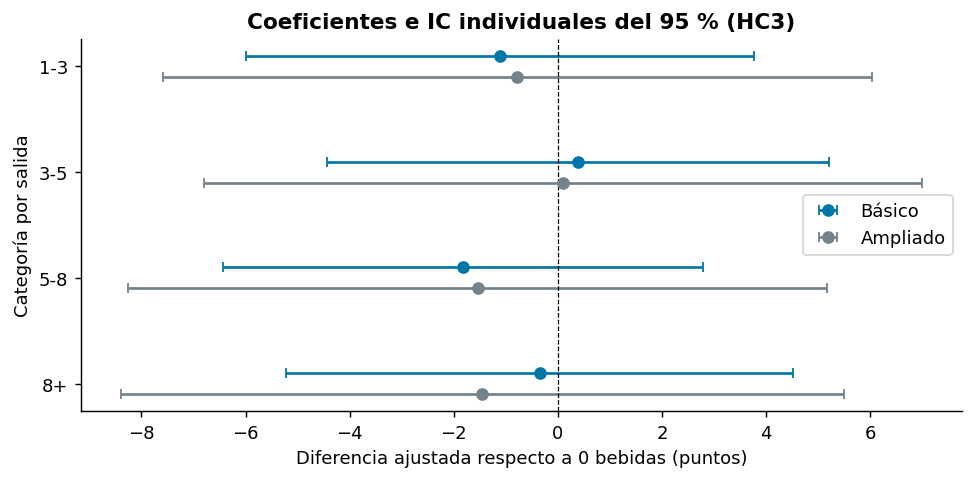

In [7]:
cons_term="C(consumo, Treatment(reference='0'))"
formula_base=f'promedio ~ {cons_term} + previo + C(sexo)'
extra='C(estudio) + C(fiestas) + C(presupuesto) + C(beca) + C(alojamiento) + C(ano)'
base_data=df.dropna(subset=['promedio','consumo','previo','sexo']).copy()
ext_data=df.dropna(subset=['promedio','consumo','previo','sexo','estudio','fiestas',
                           'presupuesto','beca','alojamiento','ano']).copy()
base=smf.ols(formula_base,data=base_data).fit(cov_type='HC3',use_t=True)
base_misma=smf.ols(formula_base,data=ext_data).fit(cov_type='HC3',use_t=True)
ampliado=smf.ols(formula_base+' + '+extra,data=ext_data).fit(cov_type='HC3',use_t=True)

def bloque(modelo,predicado):
    cols=[i for i,n in enumerate(modelo.params.index) if predicado(n)]
    R=np.eye(len(modelo.params))[cols]
    test=modelo.f_test(R)
    return {'F':float(np.asarray(test.fvalue).item()),'p':float(test.pvalue),
            'gl_num':len(cols),'gl_den':float(modelo.df_resid)}

def tabla_modelo(modelo):
    ic=modelo.conf_int()
    return pd.DataFrame({'coef':modelo.params,'se_HC3':modelo.bse,'p':modelo.pvalues,
                         'ic_inf':ic[0],'ic_sup':ic[1]})
modelos={}; tablas={}
for nombre,m in [('Basico',base),('Basico_misma_muestra',base_misma),('Ampliado',ampliado)]:
    assert np.linalg.matrix_rank(m.model.exog)==m.model.exog.shape[1], 'Diseño no identificable'
    tablas[nombre]=tabla_modelo(m)
    modelos[nombre]={'n':int(m.nobs),'parametros':len(m.params),'R2':m.rsquared,
                     'R2_ajustado':m.rsquared_adj,**bloque(m,lambda t:t.startswith('C(consumo'))}
    print(nombre,modelos[nombre]);display(tablas[nombre].round(4))
    tablas[nombre].to_csv(OUT/f'modelo_{nombre}.csv')
fig,ax=plt.subplots(figsize=(7.6,3.8))
for j,(nombre,m,color) in enumerate([('Básico',base,AZUL),('Ampliado',ampliado,GRIS)]):
    t=tabla_modelo(m);t=t.loc[[k for k in t.index if k.startswith('C(consumo')]]
    labels=[k.split('[T.')[1][:-1] for k in t.index]
    yy=np.array([niveles[1:].index(v) for v in labels])+(-.1 if j==0 else .1)
    ax.errorbar(t.coef,yy,xerr=[t.coef-t.ic_inf,t.ic_sup-t.coef],fmt='o',capsize=3,label=nombre,color=color)
ax.axvline(0,ls='--',color='black',lw=.7)
ax.set_yticks(range(4),niveles[1:]);ax.invert_yaxis()
ax.set(xlabel='Diferencia ajustada respecto a 0 bebidas (puntos)',ylabel='Categoría por salida',title='Coeficientes e IC individuales del 95 % (HC3)');ax.legend()
fig.tight_layout();fig.savefig(OUT/'modelos.png',dpi=180);plt.show()

### Diagnóstico y sensibilidad a observaciones influyentes
Se inspeccionan residuos, dispersión y observaciones con influencia alta. El criterio de Cook `4/n` es una señal de revisión, no una regla de eliminación. El ajuste principal conserva todos los casos. Se muestra un ajuste adicional excluyendo los señalados únicamente para valorar sensibilidad; esa exclusión puede cambiar la población y no se considera automáticamente superior.

El R² corresponde al ajuste en la misma muestra: no mide desempeño predictivo futuro. La variación restante puede deberse a ruido, medición, relaciones no modeladas o variables omitidas; no se atribuye enteramente a factores no medidos.

{'Cook_mayor_4_n': 23, 'max_Cook': 0.06363036353859472, 'max_leverage': 0.2891207360759457, 'BP_p': 0.12968135550247928, 'n_sensibilidad': 279, 'p_consumo_sensibilidad': 0.6312309563779612}


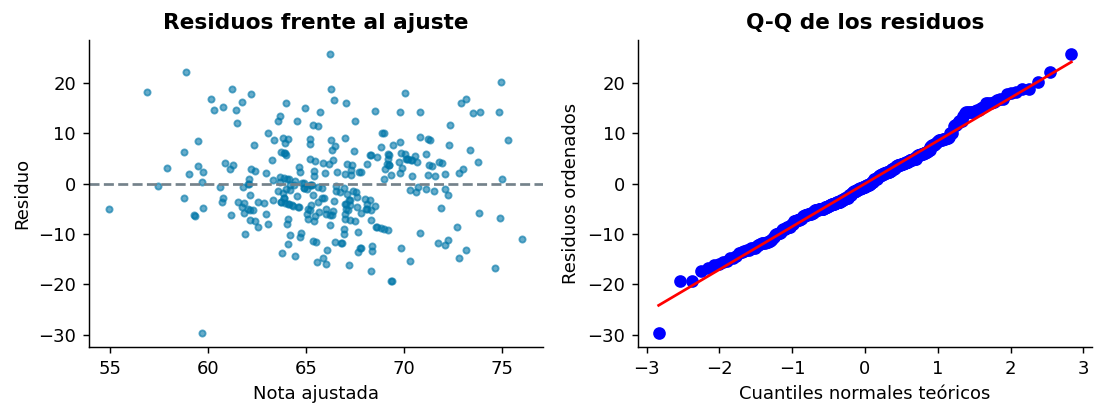

In [8]:
ols_clasico=smf.ols(formula_base+' + '+extra,data=ext_data).fit()
infl=ols_clasico.get_influence(); cook=infl.cooks_distance[0]; hat=infl.hat_matrix_diag
bp=het_breuschpagan(ols_clasico.resid,ols_clasico.model.exog)
flag=cook>4/len(ext_data)
sensible=smf.ols(formula_base+' + '+extra,data=ext_data.loc[~flag]).fit(cov_type='HC3',use_t=True)
diagnostico={'Cook_mayor_4_n':int(flag.sum()),'max_Cook':float(cook.max()),
 'max_leverage':float(hat.max()),'BP_p':float(bp[1]),
 'n_sensibilidad':int(sensible.nobs),'p_consumo_sensibilidad':bloque(sensible,lambda t:t.startswith('C(consumo'))['p']}
print(diagnostico)
fig,axs=plt.subplots(1,2,figsize=(8.6,3.3))
axs[0].scatter(ols_clasico.fittedvalues,ols_clasico.resid,s=12,alpha=.6,color=AZUL)
axs[0].axhline(0,color=GRIS,ls='--');axs[0].set(xlabel='Nota ajustada',ylabel='Residuo',title='Residuos frente al ajuste')
stats.probplot(ols_clasico.resid,plot=axs[1]);axs[1].set(title='Q-Q de los residuos', xlabel='Cuantiles normales teóricos', ylabel='Residuos ordenados')
fig.tight_layout();fig.savefig(OUT/'diagnostico.png',dpi=180);plt.show()

## 5. Moderación: preguntas exploratorias específicas
Una moderación significa que una asociación cambia según otra variable. No se infiere comparando si dos valores p separados son significativos.

Se evalúan dos interacciones de **tendencias ordinales**: rango de consumo × sexo y rango de consumo × rango de estudio. Los rangos 0,1,2,3,4 indican posiciones, no número de bebidas ni horas; esta especificación presupone linealidad de las tendencias en esos códigos. Para mantener el modelo moderado en tamaño se ajusta por promedio previo y se incluyen los efectos principales de sexo, estudio y salidas categóricas. No es el mismo ajuste del modelo socioeconómico ampliado.

Las dos interacciones se contrastan en modelos separados, con HC3 y corrección de Holm para la familia de dos pruebas. No cubren todas las posibles formas de moderación; una ausencia de significancia no descarta interacciones no lineales. Se añade, como sensibilidad distinta, la interacción completa consumo categórico × sexo (4 grados de libertad).

In [9]:
d_int=df.dropna(subset=['promedio','previo','sexo','consumo_rango','estudio_rango','fiestas']).copy()
d_int['consumo_c']=d_int.consumo_rango-d_int.consumo_rango.mean()
d_int['estudio_c']=d_int.estudio_rango-d_int.estudio_rango.mean()
fint='promedio ~ previo + consumo_c + estudio_c + C(sexo) + C(fiestas)'
ints=[]
for nombre,term in [('Sexo','consumo_c:C(sexo)'),('Estudio','consumo_c:estudio_c')]:
    m=smf.ols(fint+' + '+term,data=d_int).fit(cov_type='HC3',use_t=True)
    key=next(k for k in m.params.index if ':' in k and 'consumo_c' in k)
    ci=m.conf_int().loc[key]
    ints.append({'interaccion':nombre,'n':int(m.nobs),'coef':m.params[key],
                 'ic_inf':ci.iloc[0],'ic_sup':ci.iloc[1],'p':m.pvalues[key]})
interacciones=pd.DataFrame(ints)
interacciones['p_Holm']=multipletests(interacciones.p,method='holm')[1]
display(interacciones)
cat_int=smf.ols(f"promedio ~ {cons_term} * C(sexo) + previo + C(estudio) + C(fiestas)",data=d_int).fit(cov_type='HC3',use_t=True)
interaccion_categorica=bloque(cat_int,lambda t:':' in t and t.startswith('C(consumo'))
print('Sensibilidad categórica por sexo:',interaccion_categorica)
interacciones.to_csv(OUT/'interacciones.csv',index=False)

Sensibilidad categórica por sexo: {'F': 0.25135442811736153, 'p': 0.9087194618777236, 'gl_num': 4, 'gl_den': 298.0}


,interaccion,n,coef,ic_inf,ic_sup,p,p_Holm
0,Sexo,318,-0.323155,-2.221078,1.574767,0.737824,0.737824
1,Estudio,318,-0.344985,-1.023193,0.333224,0.317653,0.635305


## 6. Relaciones secundarias y multiplicidad
Se examina una familia explícita de seis correlaciones de Spearman con permutación: consumo con ausencias y reprobaciones; ausencias, rendimiento previo, estudio y reprobaciones con la nota. Se aplica Holm a estas seis pruebas. No se añaden pruebas hasta obtener un resultado favorable.

La pregunta de ausencias menciona expresamente el alcohol, por lo que su asociación con consumo no demuestra un mecanismo causal. Las reprobaciones son acumuladas a lo largo de los estudios y no equivalen al resultado de un único año. Ninguna correlación nula prueba la ruptura de una cadena causal. Las salidas no entran como ordinales porque `Only weekends` no tiene un orden inequívoco.

In [10]:
pares=[('Consumo y ausencias','consumo_rango','clases_rango'),
       ('Consumo y reprobaciones','consumo_rango','reprobaciones_rango'),
       ('Ausencias y nota','clases_rango','promedio'),
       ('Bachillerato y nota','previo','promedio'),
       ('Estudio y nota','estudio_rango','promedio'),
       ('Reprobaciones y nota','reprobaciones_rango','promedio')]
sec=[]
for i,(label,a,b) in enumerate(pares):
    d=df[[a,b]].dropna(); r,pv=spearman_perm(d[a],d[b],seed=SEED+10+i)
    sec.append({'relacion':label,'n':len(d),'rho':r,'p_perm':pv})
secundarias=pd.DataFrame(sec)
secundarias['p_Holm']=multipletests(secundarias.p_perm,method='holm')[1]
display(secundarias)
secundarias.to_csv(OUT/'secundarias.csv',index=False)

,relacion,n,rho,p_perm,p_Holm
0,Consumo y ausencias,403,0.416827,0.00005,0.00030
1,Consumo y reprobaciones,403,0.033716,0.49780,0.99560
2,Ausencias y nota,319,-0.108180,0.05325,0.15975
3,Bachillerato y nota,318,0.242586,0.00005,0.00030
4,Estudio y nota,320,0.021647,0.70605,0.99560
5,Reprobaciones y nota,320,-0.484412,0.00005,0.00030


## El panorama completo: correlaciones y relaciones visibles
El mapa de calor reúne dos notas y seis respuestas con orden interpretable. Presupuesto y relación con los padres se codifican por su posición, sin atribuir distancias iguales a las respuestas. Las salidas se excluyen porque «solo fines de semana» no ocupa un lugar inequívoco entre frecuencias. Se omiten nominales como sexo, facultad y alojamiento: asignarles números arbitrarios no justificaría una correlación ordinal.

Cada coeficiente usa los pares disponibles; la tabla de tamaños muestra que no todos usan las mismas personas. El mapa es descriptivo y no marca significancia. Las seis pruebas secundarias y su corrección de Holm permanecen separadas. Un color intenso no demuestra causalidad.

El segundo panel combina porcentajes de ausencias por nivel de consumo y un diagrama de dispersión de las dos notas. Su propósito es mostrar la distribución de las respuestas, sin convertir asociaciones en efectos.

Pares del mapa, fuera de diagonal: 306 a 403


,Nota universitaria,Nota de bachillerato,Consumo por salida,Estudio adicional,Ausencias por alcohol,Reprobaciones,Presupuesto,Relación con padres
Nota universitaria,1.000,0.243,-0.071,0.022,-0.108,-0.484,0.093,0.018
Nota de bachillerato,0.243,1.000,-0.104,0.221,0.017,-0.133,0.015,-0.020
Consumo por salida,-0.071,-0.104,1.000,-0.099,0.417,0.034,0.092,0.036
Estudio adicional,0.022,0.221,-0.099,1.000,-0.114,0.023,0.076,0.048
Ausencias por alcohol,-0.108,0.017,0.417,-0.114,1.000,0.062,0.052,0.053
Reprobaciones,-0.484,-0.133,0.034,0.023,0.062,1.000,0.010,-0.051
Presupuesto,0.093,0.015,0.092,0.076,0.052,0.010,1.000,0.062
Relación con padres,0.018,-0.020,0.036,0.048,0.053,-0.051,0.062,1.000


,Nota universitaria,Nota de bachillerato,Consumo por salida,Estudio adicional,Ausencias por alcohol,Reprobaciones,Presupuesto,Relación con padres
Nota universitaria,320,318,320,320,319,320,306,319
Nota de bachillerato,318,399,399,399,398,398,371,398
Consumo por salida,320,399,404,403,403,403,375,403
Estudio adicional,320,399,403,403,402,402,374,402
Ausencias por alcohol,319,398,403,402,403,402,374,402
Reprobaciones,320,398,403,402,402,403,374,402
Presupuesto,306,371,375,374,374,374,375,374
Relación con padres,319,398,403,402,402,402,374,403


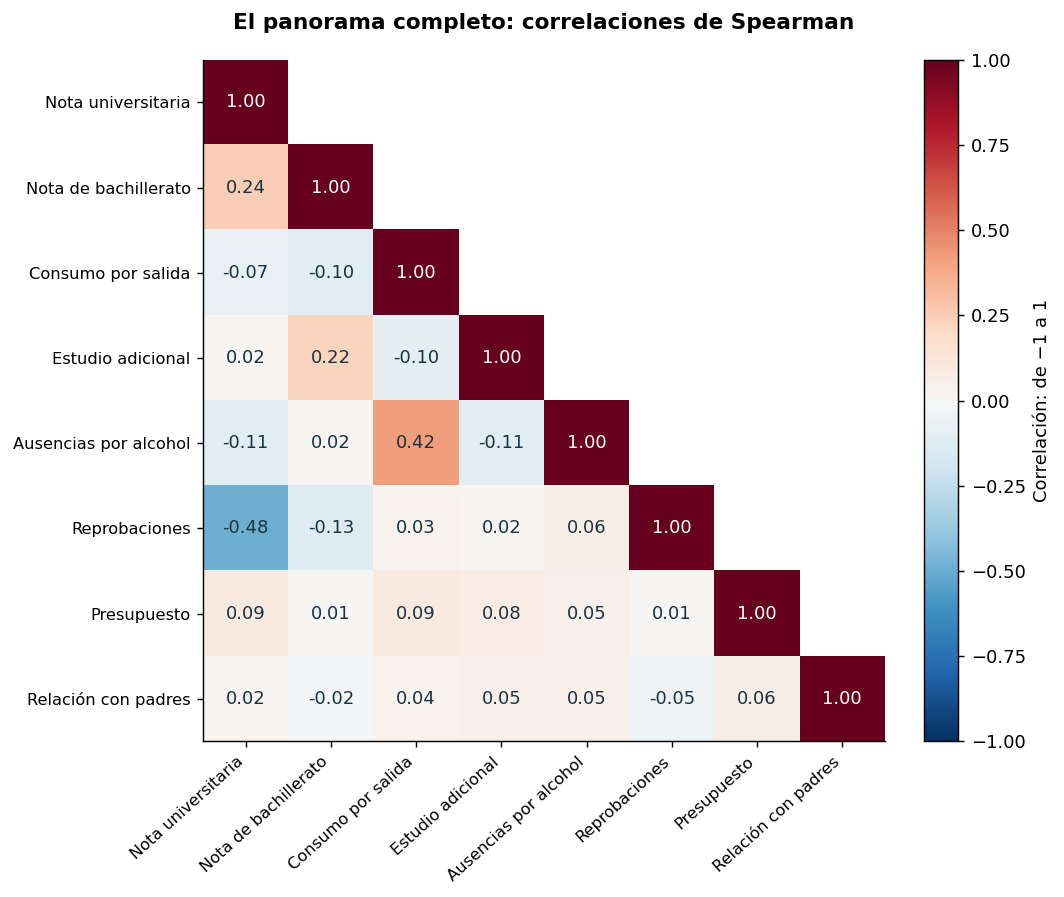

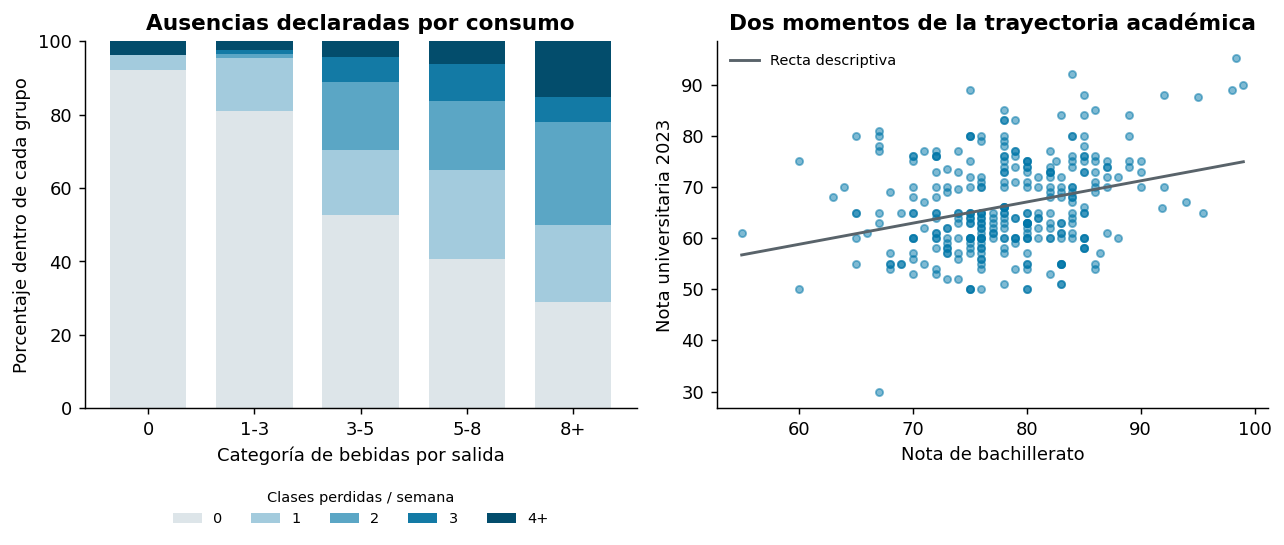

In [11]:
# Figuras adicionales del informe: cálculo a partir de los mismos datos.
pres_orden=['R 4001- R 5000','R 5001 - R 6000','R 6001 - R 7000','R 7001 - R 8000','R 8000+']
padres_orden=['Distant','Fair','Close','Very close']
for col,orden in [('presupuesto',pres_orden),('relacion_padres',padres_orden)]:
    assert set(df[col].dropna()) <= set(orden)
    df[col+'_rango']=df[col].map(dict(zip(orden,range(len(orden)))))
variables_mapa=['promedio','previo','consumo_rango','estudio_rango','clases_rango',
                'reprobaciones_rango','presupuesto_rango','relacion_padres_rango']
etiquetas_mapa=['Nota universitaria','Nota de bachillerato','Consumo por salida','Estudio adicional',
                'Ausencias por alcohol','Reprobaciones','Presupuesto','Relación con padres']
corr=df[variables_mapa].corr(method='spearman')
validos=df[variables_mapa].notna().astype(int)
n_pares=validos.T@validos
corr.index=corr.columns=etiquetas_mapa
n_pares.index=n_pares.columns=etiquetas_mapa
display(corr.round(3));display(n_pares)
corr.to_csv(OUT/'heatmap_correlaciones.csv');n_pares.to_csv(OUT/'heatmap_n_pares.csv')
fig,ax=plt.subplots(figsize=(9,7))
mat=np.ma.masked_where(np.triu(np.ones(corr.shape,dtype=bool),k=1),corr.to_numpy())
im=ax.imshow(mat,cmap='RdBu_r',vmin=-1,vmax=1)
for i in range(len(corr)):
    for j in range(i+1):
        v=corr.iloc[i,j]
        ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=10,
                color='white' if abs(v)>.55 else '#193441')
ax.set_xticks(range(len(corr)),etiquetas_mapa,rotation=42,ha='right',fontsize=9)
ax.set_yticks(range(len(corr)),etiquetas_mapa,fontsize=9)
ax.set_title('El panorama completo: correlaciones de Spearman',pad=17)
fig.colorbar(im,ax=ax,fraction=.045,pad=.04,label='Correlación: de −1 a 1')
fig.tight_layout();fig.savefig(OUT/'heatmap.png',dpi=200);plt.show()

conteos=pd.crosstab(df.consumo,df.clases).reindex(index=niveles,columns=['0','1','2','3','4+'],fill_value=0)
porcentajes=conteos.div(conteos.sum(axis=1),axis=0)*100
conteos.to_csv(OUT/'ausencias_por_consumo_conteos.csv')
porcentajes.to_csv(OUT/'ausencias_por_consumo_porcentajes.csv')
fig,axs=plt.subplots(1,2,figsize=(10,4.4))
bottom=np.zeros(5)
colores=['#DDE5E9','#A3CBDD','#5BA6C5','#137AA5','#034D6C']
for col,color in zip(porcentajes.columns,colores):
    axs[0].bar(niveles,porcentajes[col],bottom=bottom,label=col,color=color,width=.72)
    bottom+=porcentajes[col].to_numpy()
axs[0].set(title='Ausencias declaradas por consumo',ylabel='Porcentaje dentro de cada grupo',xlabel='Categoría de bebidas por salida',ylim=(0,100))
axs[0].legend(title='Clases perdidas / semana',ncol=5,loc='upper center',bbox_to_anchor=(.5,-.19),fontsize=8,title_fontsize=8,frameon=False)
s=df[['previo','promedio']].dropna()
axs[1].scatter(s.previo,s.promedio,s=16,alpha=.5,color=AZUL)
x=np.linspace(s.previo.min(),s.previo.max(),100)
a,b=np.polyfit(s.previo,s.promedio,1)
axs[1].plot(x,a*x+b,color='#59636A',lw=1.6,label='Recta descriptiva')
axs[1].set(title='Dos momentos de la trayectoria académica',xlabel='Nota de bachillerato',ylabel='Nota universitaria 2023')
axs[1].legend(frameon=False,fontsize=8)
fig.tight_layout();fig.savefig(OUT/'relaciones_visuales.png',dpi=200);plt.show()
print('Pares del mapa, fuera de diagonal:',int(n_pares.to_numpy()[np.tril_indices(8,-1)].min()),
      'a',int(n_pares.to_numpy()[np.tril_indices(8,-1)].max()))


## 7. Precisión: lo que un resultado no significativo no demuestra
La versión anterior convertía un efecto mínimo detectable con 80 % de potencia en una frontera para descartar asociaciones. Esa inferencia se elimina. Una potencia del 80 % deja una probabilidad del 20 % de no rechazar bajo la alternativa especificada; no permite descartar automáticamente esa alternativa cuando una prueba no rechaza.

Este cuaderno informa directamente un intervalo bootstrap para Spearman y un intervalo para una diferencia de medias. No se ha definido antes de ver los datos un margen de equivalencia ni se ha realizado una prueba de equivalencia. Por tanto, no se afirma equivalencia entre grupos ni ausencia de una asociación relevante. Tampoco se usa la aproximación de Fisher para Pearson como si fuera exacta para Spearman con empates.

Planificar otra encuesta requeriría definir qué diferencia importa en educación, el diseño de muestreo, la medida de consumo, el contraste, las covariables y los faltantes esperados. No se presenta un tamaño muestral universal basado únicamente en el número 320.

## 8. Límites y conclusión
- **Medición:** autorreporte; no se conocen tamaños ni graduación de bebidas; la dirección del sesgo de medición no está garantizada.
- **Tiempo:** nota de 2023 y preguntas de hábitos sin una referencia temporal uniforme. No se establece qué ocurrió antes.
- **Selección:** no se conoce el mecanismo de reclutamiento ni se puede verificar representatividad o independencia de participantes. Los IC no incorporan ese sesgo.
- **Faltantes:** posible mezcla de no aplicabilidad y ausencia de respuesta; los casos completos son una submuestra seleccionada.
- **Especificación:** los ajustes son exploratorios y no eliminan toda confusión. HC3 no sustituye un buen diseño.
- **Multiplicidad:** Holm se aplica dentro de las familias secundarias declaradas; no transforma toda la revisión en un estudio confirmatorio.

La lectura debe combinar magnitud, incertidumbre y contexto, evitando interpretar `p > 0,05` como una probabilidad de que no exista asociación. El resultado de esta encuesta no es una recomendación sobre consumo de alcohol ni una evaluación de sus consecuencias para la salud.

In [12]:
print(f"Consumo y nota: r_s={rho:.3f}, IC bootstrap 95 % [{ic_rho[0]:.3f}, {ic_rho[1]:.3f}], p de permutación={p_perm:.4f}.")
print(f"Comparación de cinco grupos: p de permutación={kw['p_permutacion']:.4f}.")
print('Los intervalos y contrastes describen incertidumbre bajo los supuestos; no prueban ausencia ni causalidad.')
print('Revisa conjuntamente el contraste de consumo en los modelos y los intervalos por categoría.')
resultados={'versiones':versiones,'sha256':sha256,'semilla':SEED,'B_bootstrap':B_BOOT,
 'B_permutaciones':B_PERM,'calidad':resumen_calidad,'principal':resultado_principal,
 'kruskal':kw,'diferencia':diferencia,'modelos':modelos,
 'coeficientes':{k:v.reset_index().rename(columns={'index':'termino'}).to_dict('records') for k,v in tablas.items()},
 'diagnostico':diagnostico,'interacciones':interacciones.to_dict('records'),
 'interaccion_categorica':interaccion_categorica,'secundarias':secundarias.to_dict('records'),
 'normalidad':normalidad,'grupos':resumen.reset_index().to_dict('records')}
(OUT/'resultados.json').write_text(json.dumps(resultados,ensure_ascii=False,indent=2),encoding='utf-8')
print('Resultados guardados en', OUT.resolve())

Consumo y nota: r_s=-0.071, IC bootstrap 95 % [-0.183, 0.043], p de permutación=0.2054.
Comparación de cinco grupos: p de permutación=0.2214.
Los intervalos y contrastes describen incertidumbre bajo los supuestos; no prueban ausencia ni causalidad.
Revisa conjuntamente el contraste de consumo en los modelos y los intervalos por categoría.
Resultados guardados en /workspace/scratch/f6ae2ac3e5b7/tmp/alcohol_run/resultados_alcohol


## Lectura de esta ejecución
La correlación observada es **−0,071**, con IC bootstrap del 95 % **[−0,183; 0,043]** y valor p por permutación **0,2054**. El contraste entre las cinco categorías da **p = 0,2214** por permutación. Estos resultados no aportan evidencia clara de asociación bajo los procedimientos considerados; no demuestran ausencia ni equivalencia.

El modelo básico usa **318 casos** y el ampliado **302**. Sus contrastes conjuntos de consumo arrojan **p = 0,542** y **p = 0,840**, respectivamente. Al ejecutar el básico sobre los mismos 302 casos, **p = 0,552**. Los intervalos por categoría son amplios; el ampliado incluye **26 parámetros** y no se presenta como un predictor validado.

Las interacciones ordinales no muestran evidencia clara: **p de Holm = 0,738** para sexo y **0,635** para estudio. La interacción categórica por sexo da **p = 0,909**. Esto no descarta cualquier forma de moderación.

Entre las relaciones secundarias, consumo y ausencias declaradas, rendimiento previo y nota, y reprobaciones y nota mantienen valores p de Holm inferiores a 0,001. Son asociaciones, no mecanismos causales identificados.

**Esta síntesis corresponde exclusivamente al CSV con el hash impreso y a las semillas declaradas. Si cambian los datos o los métodos, hay que actualizar también el texto del informe y esta síntesis.**


## Referencias y trazabilidad
Para los métodos de esta revisión se emplean referencias de inferencia y análisis de datos, además de la documentación de las bibliotecas; no se atribuyen estos procedimientos a textos de cálculo.

1. Naudé, J. *Effects of Alcohol on Student Performance*. [Kaggle](https://www.kaggle.com/datasets/joshuanaude/effects-of-alcohol-on-student-performance). Fuente declarada del CSV; copia identificada por SHA-256.
2. Efron, B. y Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall. [Edición del editor](https://www.routledge.com/An-Introduction-to-the-Bootstrap/Efron-Tibshirani/p/book/9780412042317).
3. Little, R. J. A. y Rubin, D. B. (2019). *Statistical Analysis with Missing Data*, 3.ª ed. Wiley. [DOI](https://doi.org/10.1002/9781119482260).
4. Wasserstein, R. L. y Lazar, N. A. (2016). The ASA's Statement on p-Values: Context, Process, and Purpose. *The American Statistician*, 70(2), 129-133. [DOI](https://doi.org/10.1080/00031305.2016.1154108).
5. Holm, S. (1979). A Simple Sequentially Rejective Multiple Test Procedure. *Scandinavian Journal of Statistics*, 6(2), 65-70.
6. SciPy. [Spearman](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html), documentación del coeficiente y de la aproximación de sus valores p.
7. statsmodels. [HC3](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.HC3_se.html) y [Lilliefors](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.lilliefors.html).

**Cambios respecto a la versión anterior:** redacción completa revisada; rutas locales verificables; diccionario; separación de faltantes; KS corregido; permutaciones y bootstrap; consumo y salidas categóricos en regresión; ajuste socioeconómico; IC HC3; interacciones explícitas; multiplicidad; diagnóstico de influencia; eliminación de afirmaciones de ausencia, causalidad y potencia injustificadas. Las figuras y los números del informe proceden de esta ejecución.